In [1]:
# prvotni import

import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
import sys
from numpy import pi
sys.path.append('../..')

In [2]:
# vlastni import
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
ALPHA = 1.0
T_src = 3
L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

In [5]:
from xml import dom

def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    # PDE ztrata:
    pde_output = model(pde_input)
    #print(u_t)
    laplacian = calc.laplacian(pde_input, pde_output, device=device)
    return T_src - ALPHA * laplacian

def loss_fn(model: torch.nn.Module, domain: cb.CubeDomain):
    int_pts = domain.interior.requires_grad_(True)
    res = pde_residuum(int_pts, model)
    int_loss = torch.mean((res)**2)
    
    left_pts = domain.sides[0][0].requires_grad_(True)
    right_pts = domain.sides[0][1].requires_grad_(True)

    left_out, right_out = model(left_pts), model(right_pts)
    left_loss = torch.mean(left_out**2)
    right_loss = torch.mean((right_out - 1)**2)
    
    top_pts = domain.sides[1][1]
    bot_pts = domain.sides[1][0]
    
    top_mask = (top_pts[:, 0] > -1/3) & (top_pts[:, 0] < 1/3)
    bot_mask = (bot_pts[:, 0] > -1/3) & (bot_pts[:, 0] < 1/3)
    
    top_pts = top_pts[top_mask].requires_grad_(True)
    bot_pts = bot_pts[bot_mask].requires_grad_(True)
    
    top_out, bot_out = model(top_pts), model(bot_pts)
    
    top_d_dn = calc.dir_derivative(top_pts, top_out, torch.tensor([0, 1], dtype=torch.float32, device=device), False, True)
    bot_d_dn = calc.dir_derivative(bot_pts, bot_out, torch.tensor([0, -1], dtype=torch.float32, device=device), False, True)

    top_loss = torch.mean((top_d_dn - 1)**2)
    bot_loss = torch.mean((bot_d_dn - 1)**2)

    return [int_loss, left_loss, right_loss, top_loss, bot_loss]

In [6]:
model_ctx = mm.ModelContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    input_dim=2,
    output_dim=1,
    layer=[64, 64, 64]
)

model = mm.MLPModel(model_ctx).to(device=device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=200, factor=0.75)

In [7]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=5_000,
    N_sides=[(500, 500), (500, 500), (500, 500)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)

In [8]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=loss_fn,
    epochs=20_000,
    monitor_lr=True,
)

#total_loss_values, component_loss_values = train.train_switch_to_lbfgs(train_ctx, lbfgs_lr=0.1, epochs_with_lbfgs=500)

/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


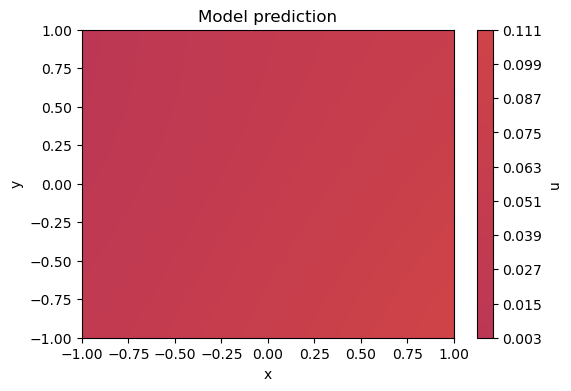

In [9]:
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=["Model prediction"],
    function_names=["u"],
    colour_map='inferno',
    vmin=-1,
    vmax=1,
    device=device,
    N=100,
    save_img=False
)

utils.plot_function_on_2d_cube([model], plot_ctx)

In [10]:
utils.plot_loss_values({"inner loss": component_loss_values[0],
                        "left-right loss": component_loss_values[1],
                        "top loss": component_loss_values[2],
                        "bot loss": component_loss_values[3]}, plot_ctx)

NameError: name 'component_loss_values' is not defined

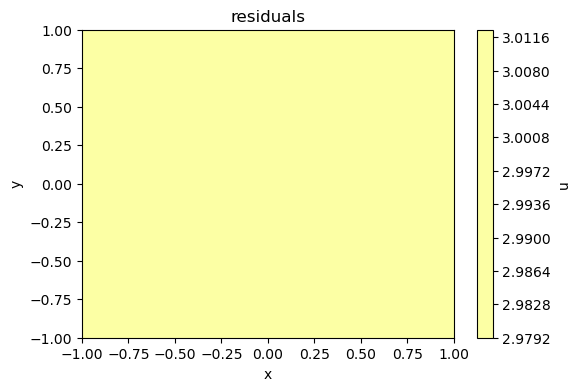

In [ ]:
plot_ctx.vmin = 0
plot_ctx.vmax = 1
plot_ctx.titles = ["residuals"]

utils.plot_function_on_2d_cube([lambda x: torch.abs(pde_residuum(x.requires_grad_(True), model))], plot_ctx)

In [12]:
def loss_hard_enforce(model: torch.nn.Module, domain: cb.CubeDomain):
    int_pts = domain.interior.requires_grad_(True)
    res = pde_residuum(int_pts, model)
    int_loss = torch.mean(res**2)
    
    return [int_loss]


def f_loss(model: torch.nn.Module, domain: cb.CubeDomain):
    top_pts = domain.sides[1][1]
    bot_pts = domain.sides[1][0]
    
    top_mask = (top_pts[:, 0] > -1/3) & (top_pts[:, 0] < 1/3)
    bot_mask = (bot_pts[:, 0] > -1/3) & (bot_pts[:, 0] < 1/3)
    
    top_pts = top_pts[top_mask].requires_grad_(True)
    bot_pts = bot_pts[bot_mask].requires_grad_(True)
    
    top_out, bot_out = model(top_pts), model(bot_pts)
    dirichelt_loss_top = torch.mean(top_out**2)
    dirichelt_loss_bot = torch.mean(bot_out**2)
    
    grad_y_top = grad(top_out, top_pts, torch.ones_like(top_out), create_graph=True)[0][:, 1]
    grad_y_bot = grad(bot_out, bot_pts, torch.ones_like(bot_out), create_graph=True)[0][:, 1]

    neumann_loss_top = torch.mean((grad_y_bot - 1)**2)
    neumann_loss_bot = torch.mean((grad_y_top - 1)**2)
    
    return [dirichelt_loss_top, dirichelt_loss_bot, neumann_loss_top, neumann_loss_bot]

def q_0_loss(model: torch.nn.Module, domain: cb.CubeDomain):
    top_pts = domain.sides[1][1]
    bot_pts = domain.sides[1][0]
    left_pts = domain.sides[0][0].requires_grad_(True)
    right_pts = domain.sides[0][1].requires_grad_(True)
    
    top_mask = (top_pts[:, 0] > -1/3) & (top_pts[:, 0] < 1/3)
    bot_mask = (bot_pts[:, 0] > -1/3) & (bot_pts[:, 0] < 1/3)
    
    top_pts = top_pts[top_mask].requires_grad_(True)
    bot_pts = bot_pts[bot_mask].requires_grad_(True)
    
    top_out = model(top_pts)
    bot_out = model(bot_pts)
    left_out = model(left_pts)
    right_out = model(right_pts)
    
    top_loss = torch.mean((top_out - 1)**2)
    bot_loss = torch.mean((bot_out - 1)**2)
    left_loss = torch.mean(left_out**2)
    right_loss = torch.mean((right_out - 1)**2)
    
    return [top_loss, bot_loss, left_loss, right_loss]

In [ ]:
domain_ctx.N_int = 1
model_ctx.layer = [32, 32, 32]

f = mm.MLPModel(model_ctx).to(device)
q_0 = mm.MLPModel(model_ctx).to(device)

f_optim = torch.optim.Adam(f.parameters(), lr=0.0001)
q_0_optim = torch.optim.Adam(q_0.parameters(), lr=0.0001)

train_ctx.model = f
train_ctx.optimizer = f_optim
train_ctx.loss_fn = f_loss

f_loss, _ = train.simple_train(train_ctx)

train_ctx.model = q_0
train_ctx.optimizer = q_0_optim
train_ctx.loss_fn = q_0_loss

q_0_loss, _ = train.simple_train(train_ctx)




Loss at epoch 1 is: 1.7142665386199951. Current learing rate: 0.0001 
Loss at epoch 100 is: 1.2274889945983887. Current learing rate: 0.0001 
Loss at epoch 200 is: 1.1384705305099487. Current learing rate: 0.0001 
Loss at epoch 300 is: 1.1099247932434082. Current learing rate: 0.0001 
Loss at epoch 400 is: 1.0847841501235962. Current learing rate: 0.0001 
Loss at epoch 500 is: 1.058624267578125. Current learing rate: 0.0001 
Loss at epoch 600 is: 1.032119870185852. Current learing rate: 0.0001 
Loss at epoch 700 is: 0.9992444515228271. Current learing rate: 0.0001 
Loss at epoch 800 is: 0.9600769281387329. Current learing rate: 0.0001 
Loss at epoch 900 is: 0.9097573757171631. Current learing rate: 0.0001 
Loss at epoch 1000 is: 0.8439730405807495. Current learing rate: 0.0001 
Loss at epoch 1100 is: 0.7590874433517456. Current learing rate: 0.0001 
Loss at epoch 1200 is: 0.6471778750419617. Current learing rate: 0.0001 
Loss at epoch 1300 is: 0.5011820793151855. Current learing rate: 

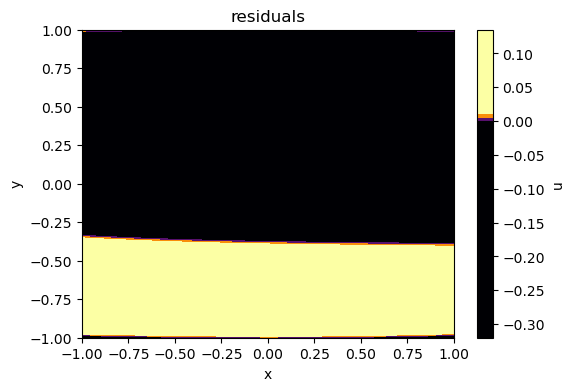

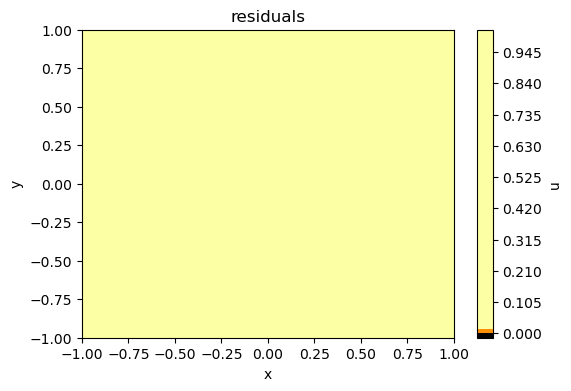

In [ ]:
utils.plot_function_on_2d_cube([f], plot_ctx)
utils.plot_function_on_2d_cube([q_0], plot_ctx)

In [14]:
def smoothing_fn(x):
    X = (x[:, 0] - 1) * (x[:, 0] + 1)
    Y1 = torch.where(x[:, 1] > 1/3, (x[:, 1] - 1/3)**2, 0.0)
    Y2 = torch.where(x[:, 1] < -1/3, (x[:, 1] + 1/3)**2, 0.0)
    
    return X * (Y1 + Y2)

def model_decorator(model_in : torch.Tensor, model_out: torch.Tensor):
    return f(model_in) * (q_0(model_in) + torch.mul(smoothing_fn(model_in), model_out))

In [15]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    layer=[64, 64, 64],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce_boundary=True,
    decorator=model_decorator
)

model_hd = mm.MLPModel(model_ctx).to(device)
hd_optim = torch.optim.Adam(model_hd.parameters(), lr=1e-4)
domain_ctx.N_int = 5_000

train_ctx.model = model_hd
train_ctx.optimizer = hd_optim
train_ctx.loss_fn = loss_hard_enforce

hd_loss, _ = train.simple_train(train_ctx)

OutOfMemoryError: CUDA out of memory. Tried to allocate 96.00 MiB. GPU 0 has a total capacity of 3.63 GiB of which 47.38 MiB is free. Including non-PyTorch memory, this process has 3.50 GiB memory in use. Of the allocated memory 3.34 GiB is allocated by PyTorch, and 95.56 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)